Завдання 1
Загрузити датасет Global YouTube Statistics 2023

1. Прочитайте CSV файл

In [5]:
import pandas as pd
import numpy as np

df_yt = pd.read_csv('Global YouTube Statistics.csv', encoding='latin-1')

2. Виведіть перші п'ять рядків

In [7]:
df_yt.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


3. Виведіть розміри датасету, перевірте наявність пропусків, дублікатів

In [10]:
print(f"Розміри датасету: {df_yt.shape}")
print(f"Кількість пропусків:\n{df_yt.isnull().sum()}")
print(f"Кількість дублікатів: {df_yt.duplicated().sum()}")

Розміри датасету: (995, 28)
Кількість пропусків:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_mon

4. Якщо є пропуски, замінить тип даних на float і середнє значення за
стовпцем.

In [11]:
numeric_cols = df_yt.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_yt[col].isnull().sum() > 0:
        df_yt[col] = df_yt[col].fillna(df_yt[col].mean())

5. Ще раз перевірте кількість пропусків.

In [14]:
print("Кількість пропусків")
print(df_yt.isnull().sum().sum())

Кількість пропусків
325


6. Перевірте, скільки унікальних країн представлено у колонці "Country"

In [15]:
unique_countries = df_yt['Country'].nunique()
print(f"Кількість унікальних країн у колонці Country: {unique_countries}")

Кількість унікальних країн у колонці Country: 49


7. Побудуйте діаграму розподілу переглядів

Text(0, 0.5, 'Частота')

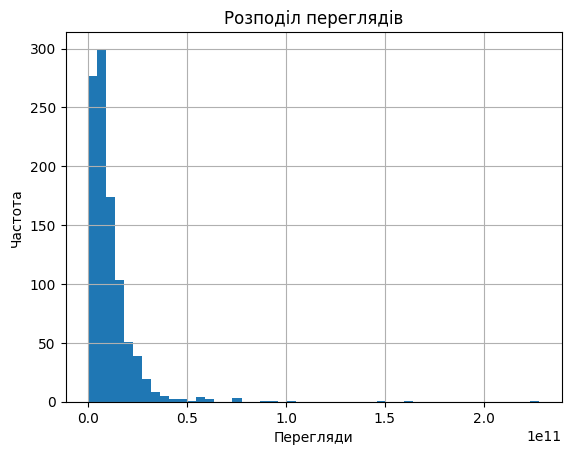

In [17]:
import matplotlib.pyplot as plt

df_yt['video views'].hist(bins=50)
plt.title('Розподіл переглядів')
plt.xlabel('Перегляди')
plt.ylabel('Частота')

8. Визначте максимальну, мінімальну, середню кількість переглядів

In [19]:
max_views = df_yt['video views'].max()
min_views = df_yt['video views'].min()
mean_views = df_yt['video views'].mean()

print(f"Максимальна кількість переглядів: {max_views}")
print(f"Мінімальна кількість переглядів: {min_views}")
print(f"Середня кількість переглядів: {mean_views}")

Максимальна кількість переглядів: 228000000000.0
Мінімальна кількість переглядів: 0.0
Середня кількість переглядів: 11039537052.03819


9. Знайдіть країну, де найбільше відео було завантажено на YouTube

In [20]:
top_country = df_yt.groupby('Country')['uploads'].sum().idxmax()
print(f"Країна з найбільшою кількістю завантажених відео: {top_country}")

Країна з найбільшою кількістю завантажених відео: India


10. Знайдіть відео з найбільшою та найменшою кількістю завантажень uploads

In [21]:
max_uploads_idx = df_yt['uploads'].idxmax()
min_uploads_idx = df_yt['uploads'].idxmin()

print(f"Відео з найбільшою кількістю завантажень: {df_yt.loc[max_uploads_idx, 'Title']}")
print(f"Відео з найменшою кількістю завантажень: {df_yt.loc[min_uploads_idx, 'Title']}")

Відео з найбільшою кількістю завантажень: ABP NEWS
Відео з найменшою кількістю завантажень: Music


2. Зчитати архів Customer Shopping Trends Dataset
Далі працюємо з файлом shopping_trends.csv
Загрузіть цей файл. Перевірте розмір таблиці, наявність пропусків, тип
стовпців. Перейменуйте назви стовпців: Змініть прописні букви на строчні
(маленькі) та пробіл на підкреслення.
Далі виконайте наступні завдання. Побудуйте графіки з використанням
бібліотеки seaborn.

1. Побудуйте гістограму віку клієнтів, використовуючи Seaborn.

Розмір таблиці: (3900, 19)
Пропуски:
customer_id                 0
age                         0
gender                      0
item_purchased              0
category                    0
purchase_amount_(usd)       0
location                    0
size                        0
color                       0
season                      0
review_rating               0
subscription_status         0
payment_method              0
shipping_type               0
discount_applied            0
promo_code_used             0
previous_purchases          0
preferred_payment_method    0
frequency_of_purchases      0
dtype: int64


Text(0.5, 1.0, 'Гістограма віку клієнтів')

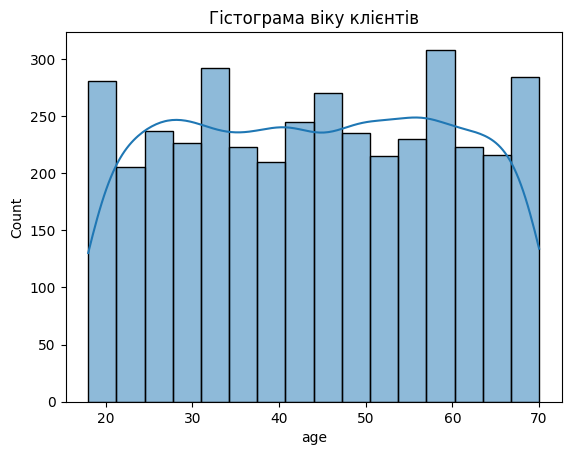

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_shop = pd.read_csv('shopping_trends.csv')
df_shop.columns = df_shop.columns.str.lower().str.replace(' ', '_')

print(f"Розмір таблиці: {df_shop.shape}")
print(f"Пропуски:\n{df_shop.isnull().sum()}")

sns.histplot(df_shop['age'], kde=True)
plt.title('Гістограма віку клієнтів')

3. Розподіл покупок за статтею (item_purchased)

Text(0.5, 1.0, 'Частота покупок за типом товару')

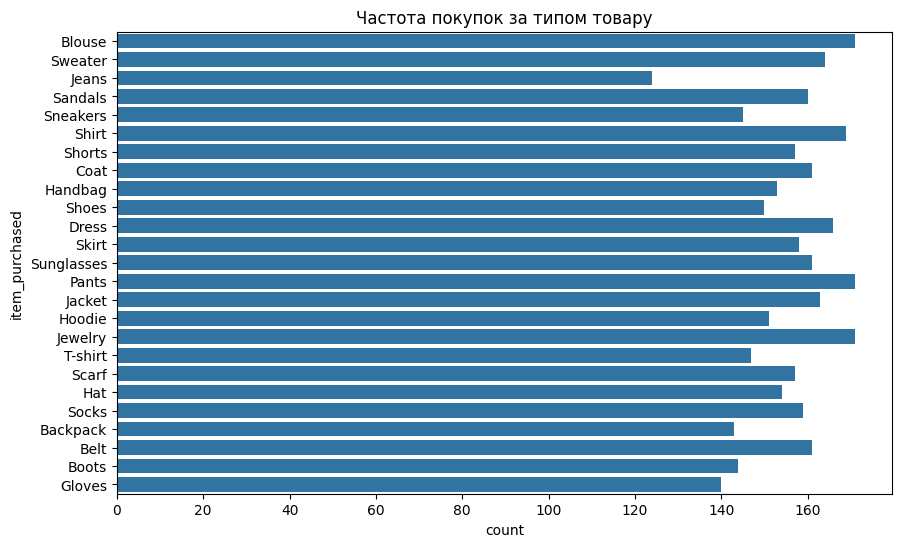

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_shop, y='item_purchased')
plt.title('Частота покупок за типом товару')

5. Залежність між віком та сумою покупок

Text(0.5, 1.0, 'Залежність віку від суми покупок')

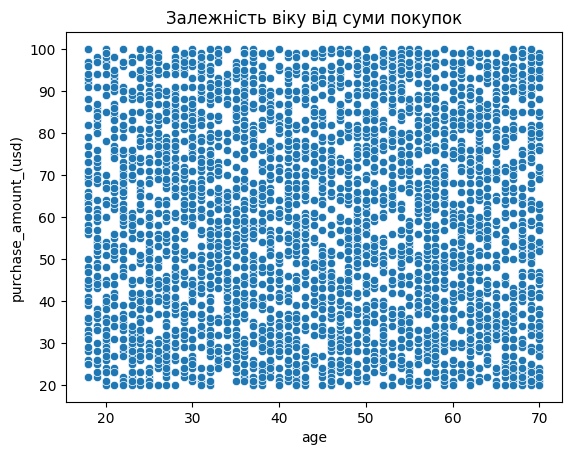

In [25]:
sns.scatterplot(data=df_shop, x='age', y='purchase_amount_(usd)')
plt.title('Залежність віку від суми покупок')

6. Графік розподілу оцінок товарів

Text(0.5, 1.0, 'Розподіл оцінок товарів')

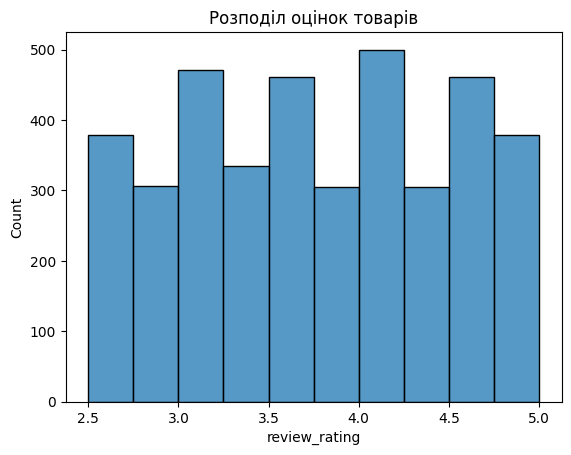

In [26]:
sns.histplot(df_shop['review_rating'], bins=10)
plt.title('Розподіл оцінок товарів')

8. Категоріальна діаграма для статі

Text(0.5, 1.0, 'Розподіл суми покупок за статтю')

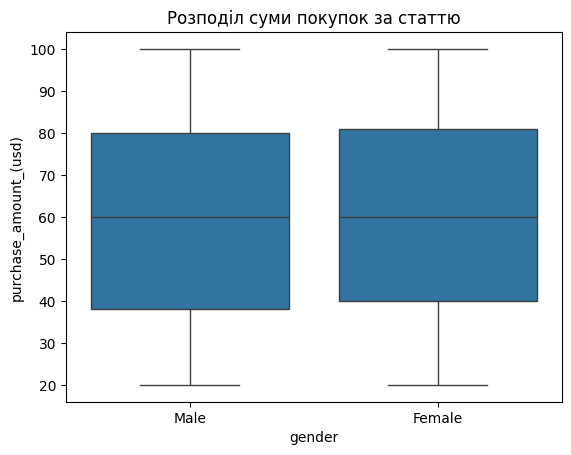

In [27]:
sns.boxplot(data=df_shop, x='gender', y='purchase_amount_(usd)')
plt.title('Розподіл суми покупок за статтю')

10. Залежність між рейтингом і сумою покупок

Text(0.5, 1.0, 'Залежність між рейтингом і сумою покупок')

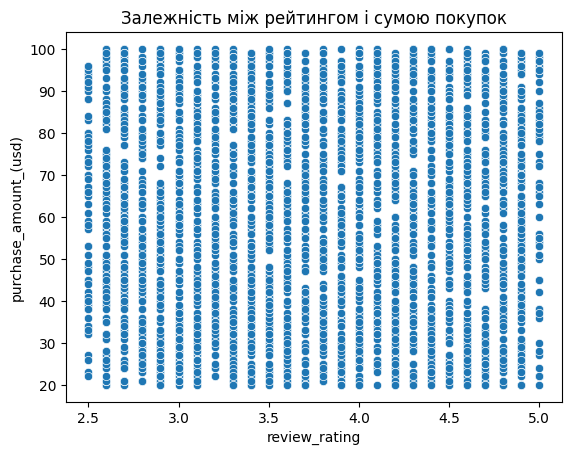

In [28]:
sns.scatterplot(data=df_shop, x='review_rating', y='purchase_amount_(usd)')
plt.title('Залежність між рейтингом і сумою покупок')

Завдання 3

1. Створіть горизонтальну діаграму з мітками на основі даних про
врожайність пшениці (data.wheat()) за допомогою бібліотеки Altair.
Задайте вісь x для врожайності пшениці, вісь y для років, а текстові
мітки відображайте значення врожайності пшениці на відповідних
роках.

In [35]:
import altair as alt
from vega_datasets import data
import plotly.express as px

wheat = data.wheat()
chart1 = alt.Chart(wheat).mark_bar().encode(
    x='wheat',
    y='year',
    text='wheat'
).mark_bar() + alt.Chart(wheat).mark_text(align='left', dx=2).encode(
    x='wheat',
    y='year',
    text='wheat'
)
chart1.display()

alt.LayerChart(...)

2. Створіть багатошарову діаграму на основі даних про виробництво
електроенергії в штаті Айова (data.iowa_electricity()) за допомогою
бібліотеки Altair . Вісь x представляє роки, вісь y відображає чисте
виробництво електроенергії (net_generation), а кожен шар діаграми
позначає різні джерела енергії (source). Встановіть прозорість (opacity)
для стовпців на рівні 0.7.

In [33]:
iowa = data.iowa_electricity()
chart2 = alt.Chart(iowa).mark_area(opacity=0.8).encode(
    x='year',
    y='net_generation',
    color='source'
)
chart2.display()

alt.Chart(...)

3. Створіть графік за допомогою бібліотеки Plotly (scatter plot) для даних
ірисів (iris dataset), де:
Вісь X (x-axis) відповідає ширині чашелистика (sepal width).
Вісь Y (y-axis) відповідає довжині чашелистика (sepal length).
Кожен пункт на графіку має розмір, який залежить від довжини
пелюстки (petal length).
Кожен пункт на графіку має різний колір в залежності від виду
(species).
При наведенні на пункт повинні відображатися додаткові дані, такі як
ширина пелюстки (petal width)

In [34]:
iris = data.iris()
fig = px.scatter(iris, x='sepalWidth', y='sepalLength',
                 size='petalLength', color='species',
                 hover_data=['petalWidth'])

fig.show()